In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# Load files
base = Path("activations")

harmful = np.load(base / "harmful_activations.npy")
harmless = np.load(base / "harmless_activations.npy")
utility = np.load(base / "utility_activations.npy")

print("harmful:", harmful.shape)
print("harmless:", harmless.shape)
print("utility:", utility.shape)

harmful: (100, 27, 1152)
harmless: (100, 27, 1152)
utility: (100, 27, 1152)


In [ ]:
# Setup and functions
num_layers = harmful.shape[1]
hidden_dim = harmful.shape[2]
k = min(10, hidden_dim, harmful.shape[0], harmless.shape[0], utility.shape[0])

print(f"num_layers: {num_layers}, hidden_dim: {hidden_dim}, k: {k}")

def orthonormal_basis_from_svd(X, k):
    X = X - X.mean(axis=0, keepdims=True)
    _, S, Vt = np.linalg.svd(X, full_matrices=False)
    basis = Vt[:k].T
    return basis, S[:k]

def orthogonalize_subspace(U_target, U_reference):
    # Efficient: avoid building full (hidden_dim, hidden_dim) projection matrix
    U_proj_removed = U_target - U_reference @ (U_reference.T @ U_target)
    Q, R = np.linalg.qr(U_proj_removed)
    # Only keep columns where R diagonal is non-negligible (avoid rank-deficient basis)
    rank = np.sum(np.abs(np.diag(R)) > 1e-6)
    return Q[:, :max(rank, 1)]

def principal_angle_cosines(U1, U2):
    _, s, _ = np.linalg.svd(U1.T @ U2, full_matrices=False)
    return np.clip(s, 0, 1)  # clip for numerical stability

def subspace_overlap_score(U1, U2):
    s = principal_angle_cosines(U1, U2)
    return float(np.mean(s**2))

num_layers: 27, hidden_dim: 1152, k: 10


In [ ]:
# ActSVD main loop
safety_subspaces = []
utility_subspaces = []
safety_subspaces_orth = []
overlap_scores = []
top_sv_overlap = []

for layer in range(num_layers):
    H = harmful[:, layer, :]
    A = harmless[:, layer, :]
    U = utility[:, layer, :]

    A_mean = A.mean(axis=0, keepdims=True)

    D_safety = H - A_mean
    D_utility = U - A_mean

    U_s, S_s = orthonormal_basis_from_svd(D_safety, k)
    U_u, S_u = orthonormal_basis_from_svd(D_utility, k)

    U_s_orth = orthogonalize_subspace(U_s, U_u)

    safety_subspaces.append(U_s)
    utility_subspaces.append(U_u)
    safety_subspaces_orth.append(U_s_orth)

    svals = principal_angle_cosines(U_s, U_u)
    top_sv_overlap.append(float(svals[0]))
    overlap_scores.append(subspace_overlap_score(U_s, U_u))

print("ActSVD extraction complete.")

ActSVD extraction complete.


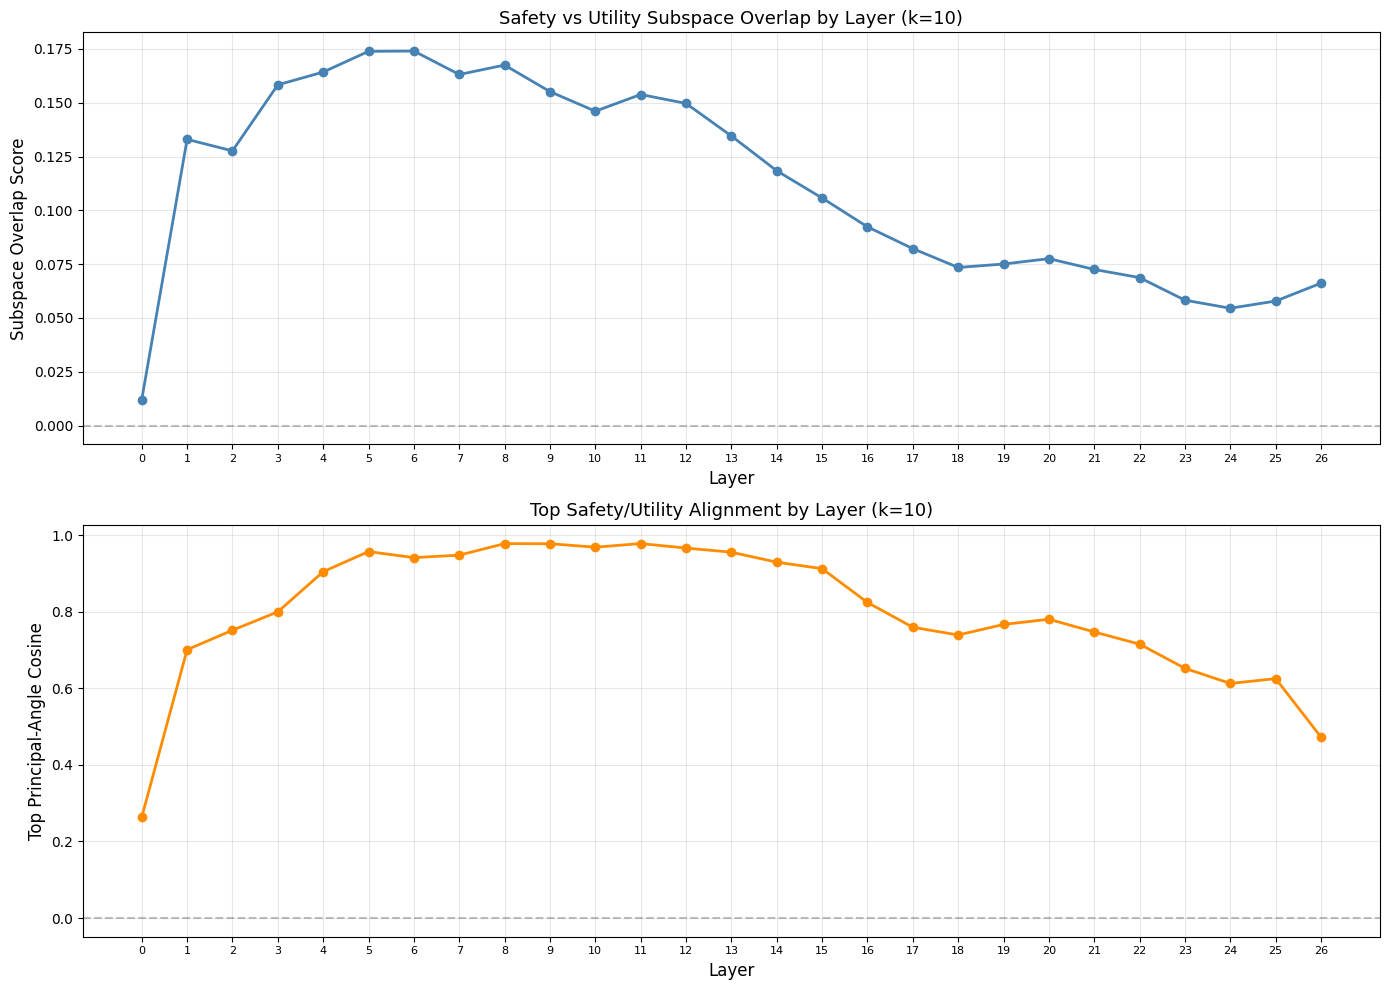

In [ ]:
# Plots 
layers = list(range(num_layers))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: subspace overlap score
axes[0].plot(layers, overlap_scores, marker="o", linewidth=2, color="steelblue")
axes[0].set_xlabel("Layer", fontsize=12)
axes[0].set_ylabel("Subspace Overlap Score", fontsize=12)
axes[0].set_title(f"Safety vs Utility Subspace Overlap by Layer (k={k})", fontsize=13)
axes[0].set_xticks(layers)
axes[0].set_xticklabels(layers, fontsize=8)
axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Plot 2: top principal angle cosine
axes[1].plot(layers, top_sv_overlap, marker="o", linewidth=2, color="darkorange")
axes[1].set_xlabel("Layer", fontsize=12)
axes[1].set_ylabel("Top Principal-Angle Cosine", fontsize=12)
axes[1].set_title(f"Top Safety/Utility Alignment by Layer (k={k})", fontsize=13)
axes[1].set_xticks(layers)
axes[1].set_xticklabels(layers, fontsize=8)
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("actsvd_overlap_plots.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# Layer ranking
best_separated = np.argsort(overlap_scores)[:5]
most_overlapping = np.argsort(overlap_scores)[-5:]

print("Most separated layers:", best_separated)
print("Most overlapping layers:", most_overlapping)

Most separated layers: [ 0 24 25 23 26]
Most overlapping layers: [7 4 8 5 6]


In [30]:
#  Summary statistics 

import numpy as np

# Overall range
print("=== OVERALL OVERLAP SCORES ===")
print(f"Min overlap score: {min(overlap_scores):.4f}  (layer {np.argmin(overlap_scores)})")
print(f"Max overlap score: {max(overlap_scores):.4f}  (layer {np.argmax(overlap_scores)})")
print(f"Mean overlap score: {np.mean(overlap_scores):.4f}")

print("\n=== TOP PRINCIPAL ANGLE COSINE ===")
print(f"Min: {min(top_sv_overlap):.4f}  (layer {np.argmin(top_sv_overlap)})")
print(f"Max: {max(top_sv_overlap):.4f}  (layer {np.argmax(top_sv_overlap)})")

print("\n=== LAYER GROUPS ===")
# Early layers 0-9
early = overlap_scores[:10]
print(f"Early layers (0-9):  mean overlap = {np.mean(early):.4f}")

# Middle layers 10-18
mid = overlap_scores[10:19]
print(f"Middle layers (10-18): mean overlap = {np.mean(mid):.4f}")

# Late layers 19-26
late = overlap_scores[19:]
print(f"Late layers (19-26): mean overlap = {np.mean(late):.4f}")

print("\n=== MOST SEPARATED LAYERS ===")
best = np.argsort(overlap_scores)[:5]
for l in best:
    print(f"  Layer {l}: overlap = {overlap_scores[l]:.4f}")

print("\n=== MOST OVERLAPPING LAYERS ===")
worst = np.argsort(overlap_scores)[-5:]
for l in worst:
    print(f"  Layer {l}: overlap = {overlap_scores[l]:.4f}")

print("\n=== DoM vs ActSVD ALIGNMENT ===")
print(f"Safety alignment mean:  {np.mean(dom_vs_actsvd_safety):.4f}")
print(f"Safety alignment min:   {min(dom_vs_actsvd_safety):.4f}  (layer {np.argmin(dom_vs_actsvd_safety)})")
print(f"Safety alignment max:   {max(dom_vs_actsvd_safety):.4f}  (layer {np.argmax(dom_vs_actsvd_safety)})")

print(f"\nUtility alignment mean: {np.mean(dom_vs_actsvd_utility):.4f}")
print(f"Utility alignment min:  {min(dom_vs_actsvd_utility):.4f}  (layer {np.argmin(dom_vs_actsvd_utility)})")
print(f"Utility alignment max:  {max(dom_vs_actsvd_utility):.4f}  (layer {np.argmax(dom_vs_actsvd_utility)})")

print("\n=== OVERALL INTERPRETATION ===")
mean_overlap = np.mean(overlap_scores)
if mean_overlap < 0.2:
    print("→ Safety and utility are largely ORTHOGONAL (independent)")
elif mean_overlap < 0.5:
    print("→ Safety and utility show MODERATE overlap (partial entanglement)")
else:
    print("→ Safety and utility are strongly ENTANGLED")

=== OVERALL OVERLAP SCORES ===
Min overlap score: 0.0120  (layer 0)
Max overlap score: 0.1740  (layer 6)
Mean overlap score: 0.1117

=== TOP PRINCIPAL ANGLE COSINE ===
Min: 0.2635  (layer 0)
Max: 0.9788  (layer 11)

=== LAYER GROUPS ===
Early layers (0-9):  mean overlap = 0.1429
Middle layers (10-18): mean overlap = 0.1174
Late layers (19-26): mean overlap = 0.0663

=== MOST SEPARATED LAYERS ===
  Layer 0: overlap = 0.0120
  Layer 24: overlap = 0.0545
  Layer 25: overlap = 0.0578
  Layer 23: overlap = 0.0582
  Layer 26: overlap = 0.0661

=== MOST OVERLAPPING LAYERS ===
  Layer 7: overlap = 0.1631
  Layer 4: overlap = 0.1643
  Layer 8: overlap = 0.1675
  Layer 5: overlap = 0.1739
  Layer 6: overlap = 0.1740

=== DoM vs ActSVD ALIGNMENT ===
Safety alignment mean:  0.4807
Safety alignment min:   0.0166  (layer 20)
Safety alignment max:   0.9437  (layer 13)

Utility alignment mean: 0.4104
Utility alignment min:  0.0131  (layer 22)
Utility alignment max:  0.9368  (layer 9)

=== OVERALL INTE